<a href="https://colab.research.google.com/github/lstrsrmn/drug-verification/blob/feat%2Fjess-suggested-vclScalar/training_monitor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Drug Verification — Training Monitor

This notebook trains the PK/PD neural network controller and provides detailed monitoring of training behaviour for evaluation.

**Branch:** `feat/better-project-structure`  
**Repo:** [ggustavs/drug-verification](https://github.com/ggustavs/drug-verification)

### Sections
1. Setup
2. Data Generation
3. Preprocessing
4. Model Definition
5. Training with Monitoring
6. Evaluation
7. Diagnostic Plots

## 1. Setup

In [3]:
import os, sys

# Clone the repo if running in Colab
if 'google.colab' in sys.modules:
    if not os.path.exists('drug-verification'):
        !git clone --branch feat/jess-suggested-vclScalar https://github.com/lstrsrmn/drug-verification.git
    os.chdir('drug-verification')

    # Add src/ to path so drug_verification package is importable without editable install
    if os.path.abspath('src') not in sys.path:
        sys.path.insert(0, os.path.abspath('src'))

    # Install only the deps needed for training — skips vehicle-lang and torch
    !pip install -q tensorflow scikit-learn matplotlib pandas numpy

# Allow TF to grow GPU memory rather than reserving all of it
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # suppress info logs

print('Working directory:', os.getcwd())

Cloning into 'drug-verification'...
remote: Enumerating objects: 158, done.
remote: Counting objects: 100% (158/158), done.
remote: Compressing objects: 100% (104/104), done.
remote: Total 158 (delta 69), reused 138 (delta 49), pack-reused 0 (from 0)
Receiving objects: 100% (158/158), 726.96 KiB | 7.65 MiB/s, done.
Resolving deltas: 100% (69/69), done.
Working directory: /content/drug-verification/drug-verification


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from drug_verification.simulation import simulate_cohort
from drug_verification.training import build_model, prepare_data, evaluate_model
from drug_verification.types import SimulationConfig
from drug_verification import constants as C

print('TensorFlow:', tf.__version__)
print('GPU available:', bool(tf.config.list_physical_devices('GPU')))

TensorFlow: 2.19.0
GPU available: False


## 2. Data Generation

Simulate a cohort of patients using the PK/PD model. All randomness is seeded for reproducibility.

In [5]:
# --- Configuration --- edit these to experiment
NUM_PATIENTS = 50
TIMESTEPS    = 48
EPOCHS       = 50
BATCH_SIZE   = 32
SEED         = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)

In [6]:
cfg = SimulationConfig(num_patients=NUM_PATIENTS, timesteps=TIMESTEPS, seed=SEED)
X, y = simulate_cohort(cfg, seed=SEED)

print(f'Samples:  {X.shape[0]}')
print(f'Features: {X.shape[1]}  (C, T, WBC, Age, Weight)')
print(f'Target:   dose (mg)')
print()
print('Feature ranges:')
feature_names = ['C (conc)', 'T (temp)', 'WBC', 'Age', 'Weight']
for i, name in enumerate(feature_names):
    print(f'  {name:12s}  min={X[:,i].min():.2f}  max={X[:,i].max():.2f}  mean={X[:,i].mean():.2f}')
print(f'  {"Dose":12s}  min={y.min():.2f}  max={y.max():.2f}  mean={y.mean():.2f}')

Samples:  2350
Features: 5  (C, T, WBC, Age, Weight)
Target:   dose (mg)

Feature ranges:
  C (conc)      min=0.00  max=33.71  mean=13.42
  T (temp)      min=36.92  max=39.96  mean=37.74
  WBC           min=7.63  max=19.81  mean=11.89
  Age           min=18.00  max=89.00  mean=50.64
  Weight        min=50.35  max=99.16  mean=76.38
  Dose          min=0.00  max=493.14  mean=48.64


## 3. Preprocessing

Scaler is fit on the training split only to avoid data leakage.

In [7]:
X_train, X_test, y_train, y_test, scaler = prepare_data(X, y, seed=SEED)

print(f'Train: {X_train.shape[0]} samples')
print(f'Test:  {X_test.shape[0]} samples')
print()
print('Scaler mean: ', np.round(scaler.mean_, 4))
print('Scaler std:  ', np.round(scaler.scale_, 4))
print()
print('NOTE: These values must match meanScalingValues / standardDeviationValues in pk.vcl')
print('      They are auto-updated when you run `pk train` locally.')

Train: 1880 samples
Test:  470 samples

Scaler mean:  [13.4343 37.7307 11.876  50.8032 76.4416]
Scaler std:   [ 7.3122  0.6204  2.5428 23.1667 14.3958]

NOTE: These values must match meanScalingValues / standardDeviationValues in pk.vcl
      They are auto-updated when you run `pk train` locally.


## 4. Model Definition

In [8]:
model = build_model(X_train.shape[1])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,089 (35.50 KB)

 Trainable params: 9,089 (35.50 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Training with Monitoring

Custom callback records per-epoch max absolute error alongside the standard loss metrics.

In [9]:
class MaxAbsoluteErrorCallback(tf.keras.callbacks.Callback):
    """Records max absolute error on the validation set each epoch."""
    def __init__(self, X_val, y_val):
        super().__init__()
        self.X_val = X_val
        self.y_val = y_val
        self.max_errors = []

    def on_epoch_end(self, epoch, logs=None):
        preds = self.model.predict(self.X_val, verbose=0).flatten()
        max_err = float(np.max(np.abs(preds - self.y_val.flatten())))
        self.max_errors.append(max_err)
        print(f'  val_max_abs_err: {max_err:.2f} mg')

max_err_cb = MaxAbsoluteErrorCallback(X_test, y_test)

In [10]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[max_err_cb],
)

Epoch 1/50
57/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12305.4164 - mae: 47.9652  val_max_abs_err: 460.98 mg
59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 11828.0781 - mae: 46.6231 - val_loss: 12511.7129 - val_mae: 49.5309
Epoch 2/50
56/59 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 10017.4220 - mae: 42.4532  val_max_abs_err: 336.85 mg
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 8373.9893 - mae: 38.7848 - val_loss: 5799.4297 - val_mae: 35.1429
Epoch 3/50
57/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3829.8804 - mae: 28.8367  val_max_abs_err: 186.43 mg
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2620.5386 - mae: 25.1880 - val_loss: 1121.4202 - val_mae: 19.3536
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 894.1265 - mae: 16.2066  val_max_abs_err: 138.23 mg
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 610.5931 - mae: 12.7446 - val_loss: 362.3536 - val_mae: 9.7027
Epoch 5/50
57/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 358.6072 - mae: 9.6558   val_max_abs_err: 1

## 6. Evaluation

In [11]:
metrics = evaluate_model(model, X_test, y_test)
print('Test set evaluation')
print(f'  MSE:               {metrics["mse"]:.4f}')
print(f'  MAE:               {metrics["mae"]:.4f}')
print(f'  Max absolute error: {metrics["max_absolute_error"]:.4f} mg  ← worst-case overdose prediction')

Test set evaluation
  MSE:               64.2530
  MAE:               3.9703
  Max absolute error: 73.9767 mg  ← worst-case overdose prediction


## 7. Diagnostic Plots

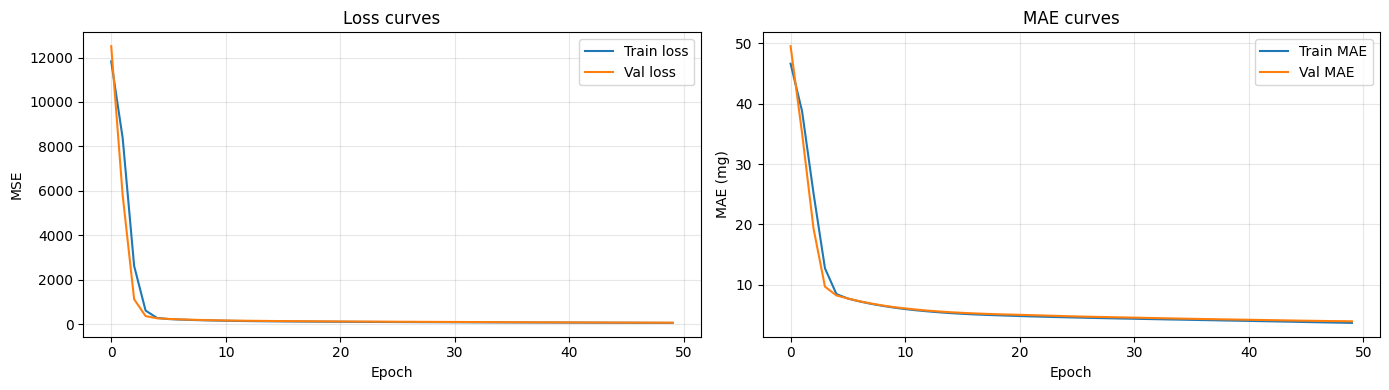

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss curves
ax = axes[0]
ax.plot(history.history['loss'], label='Train loss')
ax.plot(history.history['val_loss'], label='Val loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE')
ax.set_title('Loss curves')
ax.legend()
ax.grid(True, alpha=0.3)

# MAE curves
ax = axes[1]
ax.plot(history.history['mae'], label='Train MAE')
ax.plot(history.history['val_mae'], label='Val MAE')
ax.set_xlabel('Epoch')
ax.set_ylabel('MAE (mg)')
ax.set_title('MAE curves')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

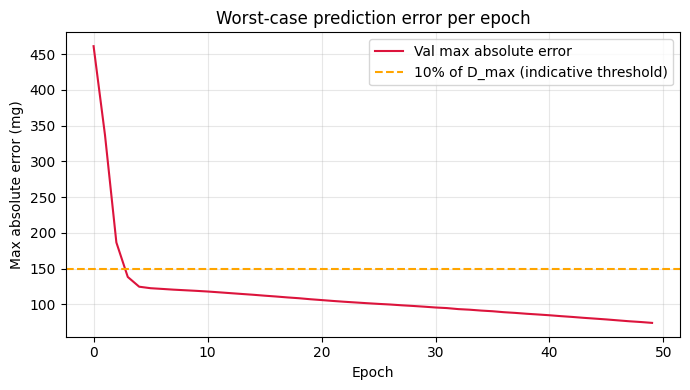

In [13]:
plt.figure(figsize=(7, 4))
plt.plot(max_err_cb.max_errors, color='crimson', label='Val max absolute error')
plt.axhline(C.D_MAX * 0.1, color='orange', linestyle='--', label='10% of D_max (indicative threshold)')
plt.xlabel('Epoch')
plt.ylabel('Max absolute error (mg)')
plt.title('Worst-case prediction error per epoch')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

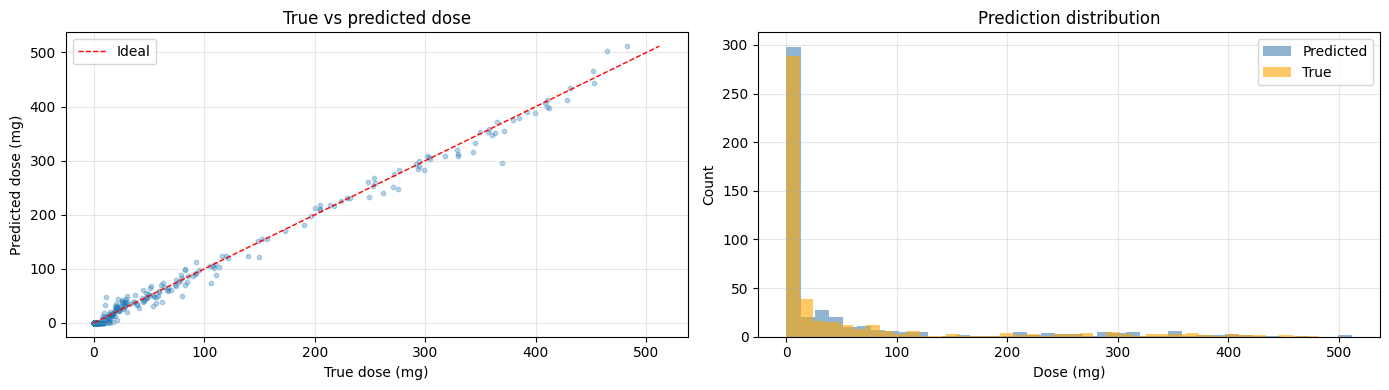

Predictions at zero: 282 / 470 (60.0%)  ← ReLU collapse check


In [14]:
y_pred = model.predict(X_test, verbose=0).flatten()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# True vs predicted
ax = axes[0]
ax.scatter(y_test.flatten(), y_pred, alpha=0.3, s=10)
lims = [0, max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, 'r--', linewidth=1, label='Ideal')
ax.set_xlabel('True dose (mg)')
ax.set_ylabel('Predicted dose (mg)')
ax.set_title('True vs predicted dose')
ax.legend()
ax.grid(True, alpha=0.3)

# Prediction distribution
ax = axes[1]
ax.hist(y_pred, bins=40, alpha=0.6, label='Predicted', color='steelblue')
ax.hist(y_test.flatten(), bins=40, alpha=0.6, label='True', color='orange')
ax.set_xlabel('Dose (mg)')
ax.set_ylabel('Count')
ax.set_title('Prediction distribution')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

zero_preds = np.sum(y_pred == 0)
print(f'Predictions at zero: {zero_preds} / {len(y_pred)} ({100*zero_preds/len(y_pred):.1f}%)  ← ReLU collapse check')

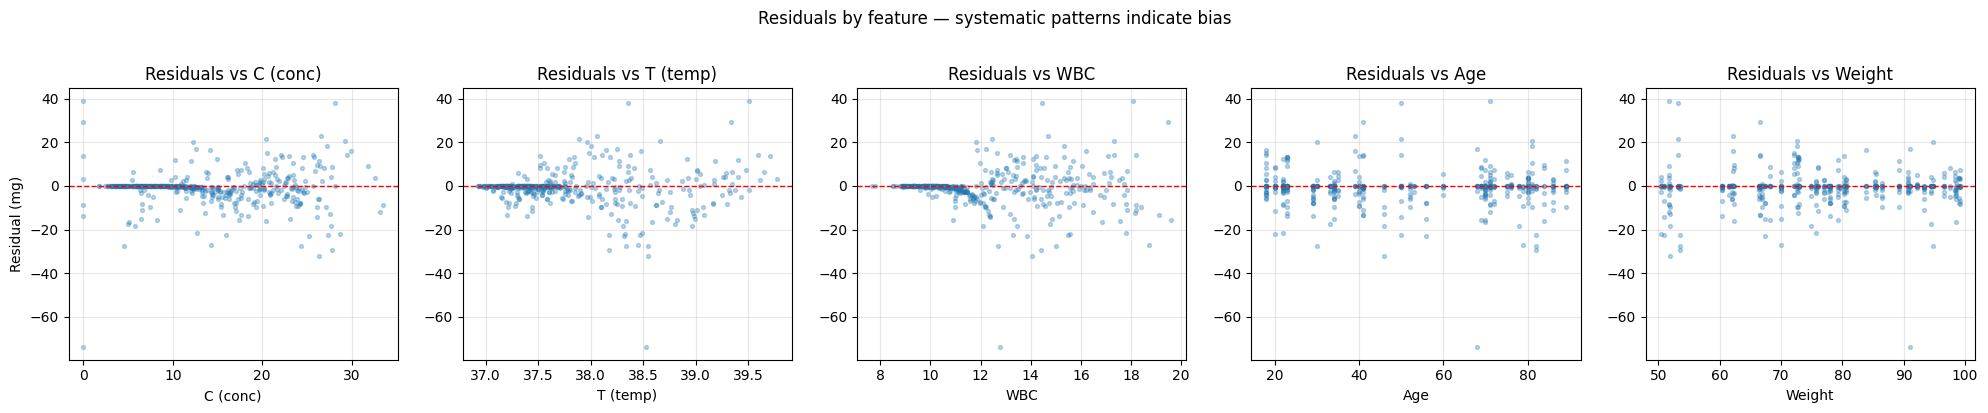

In [15]:
residuals = y_pred - y_test.flatten()
feature_names = ['C (conc)', 'T (temp)', 'WBC', 'Age', 'Weight']

# Unscale X_test back to original space for interpretable axes
X_test_raw = scaler.inverse_transform(X_test)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, (ax, name) in enumerate(zip(axes, feature_names)):
    ax.scatter(X_test_raw[:, i], residuals, alpha=0.3, s=8)
    ax.axhline(0, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel(name)
    ax.set_ylabel('Residual (mg)' if i == 0 else '')
    ax.set_title(f'Residuals vs {name}')
    ax.grid(True, alpha=0.3)

plt.suptitle('Residuals by feature — systematic patterns indicate bias', y=1.02)
plt.tight_layout()
plt.show()